In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [1]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.4 MB/s eta 0:00:0000:0100:01


# Step 1: Download images of cats and non-cats

In [14]:
from ddgs import DDGS
from fastcore.all import *
import time,json
def search_images(keywords, max_images=200):
    return L(DDGS().images(keywords,max_results=max_images)).itemgot('image')
    


** Testing the search functions works correctly , it returns the URL of the images from the internet**

In [15]:
urls=search_images('cat photos',max_images=1)
urls[0]

'https://images.pexels.com/photos/3777622/pexels-photo-3777622.jpeg?cs=srgb&dl=pexels-just-a-couple-photos-3777622.jpg&fm=jpg'

**Download a Url and take a look at it**

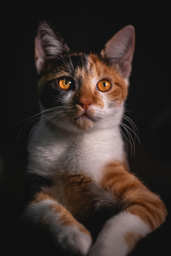

In [17]:
from fastdownload import download_url
dest='cat.jpg'
download_url(urls[0],dest,show_progress=False)
from fastai.vision.all import *
im=Image.open(dest)
im.to_thumb(256,256)

**lets do the same with dog images**

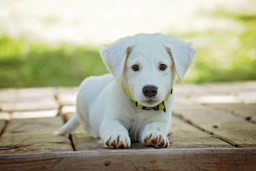

In [18]:
download_url(search_images('dog photos', max_images=1)[0], 'dog.jpg', show_progress=False)
Image.open('dog.jpg').to_thumb(256,256)

**It seems like the functions are working as thought. Let's grab a few examples of each of "cat" and "dog' photos, and save each group of photos to a different folder**

In [21]:
searches='cat','dog'
path=Path('cat_or_not')
for o in searches:
    dest=(path/o)
    dest.mkdir(exist_ok=True,parents=True)
    download_images(dest,urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o,max_size=400,dest=path/o)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


# Step 2: Train the model

In [22]:
failed=verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

1

**Creating Dataloaders in fastai that is Datablock**

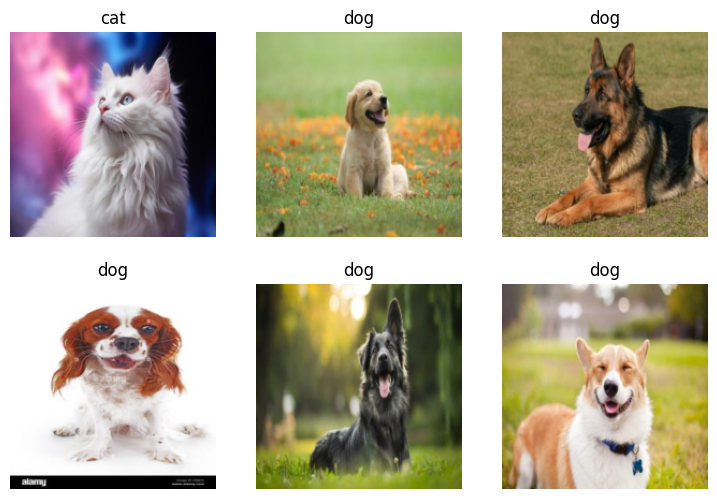

In [25]:
dls= DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2,seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192,method='squish')]
).dataloaders(path,bs=32)
dls.show_batch(max_n=6)

We use **resnet18** computer vision model

In [26]:
learn=vision_learner(dls,resnet18,metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.145677,0.075996,0.027027,00:09


epoch,train_loss,valid_loss,error_rate,time
0,0.168092,0.029695,0.027027,00:14
1,0.134053,0.009948,0.000000,00:13
2,0.091790,0.002972,0.000000,00:14


# Step 3: Use the trained model for prediction

In [29]:
is_cat,_,probs= learn.predict(PILImage.create('cat.jpg'))
print(f"This is a :{is_cat}.")
print(f"Probability it's a cat:  {probs[0]:.4f}")

This is a :cat.
Probability it's a cat:  1.0000
